# Feature Engineering and Modelling

## FeatureEngineering

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import matplotlib.dates as mdates

df_jun = pd.read_csv("clean_jun_v2.csv")

In [6]:
def engineer_ramp_features(df):
    df = df.copy()
    
    # 🌟 NEW: Ensure the index is DatetimeIndex
    if not isinstance(df.index, pd.DatetimeIndex):
        if 'TIMESTAMP' in df.columns:
            df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
            df = df.set_index('TIMESTAMP').sort_index()
        else:
            raise TypeError("The dataframe must have a DatetimeIndex or a 'TIMESTAMP' column.")

    # A. Resample to 30-Minute Mean
    df_30 = df.resample('30T').mean()
    
    # B. Cyclical Temporal Features
    df_30['hour_sin'] = np.sin(2 * np.pi * df_30.index.hour / 24)
    df_30['hour_cos'] = np.cos(2 * np.pi * df_30.index.hour / 24)
    df_30['doy_sin']  = np.sin(2 * np.pi * df_30.index.dayofyear / 365.25)
    df_30['doy_cos']  = np.cos(2 * np.pi * df_30.index.dayofyear / 365.25)

    # C. Velocity & Acceleration (Ramp Mechanics)
    df_30['v_solar'] = df_30['solar_kw'].diff()
    df_30['a_solar'] = df_30['v_solar'].diff()
    df_30['solar_volatility_2h'] = df_30['solar_kw'].rolling(window=4).std()
    
    # D. Environmental Interaction
    if 'rh_avg' in df_30.columns:
        df_30['v_humidity'] = df_30['rh_avg'].diff()
        df_30['humidity_solar_risk'] = (df_30['rh_avg'] / 100) * (1 - df_30['solar_kw'])

    # E. SURGICAL MEMORY
    physical_sensors = ['solar_kw', 'net_rad_wm2', 'temp_c', 'rh_avg', 'wind_speed_ms', 'wind_dir', 'rain_mm']
    lag_cols = [c for c in physical_sensors if c in df_30.columns]

    for col in lag_cols:
        df_30[f'{col}_lag_6h'] = df_30[col].shift(12)
        df_30[f'{col}_lag_24h'] = df_30[col].shift(48)
        
    # F. 30m Step-by-Step History
    for i in range(1, 7): 
        df_30[f'solar_lag_{i*30}m'] = df_30['solar_kw'].shift(i)

    # G. Clear Sky Proxy & Wind Vectors
    df_30['solar_time_ratio'] = df_30['solar_kw'] / (df_30['hour_sin'] + 0.1)
    df_30['solar_time_ratio'] = df_30['solar_time_ratio'].clip(0, 5)
    
    wd_rad = np.radians(df_30['wind_dir'])
    df_30['wind_x'] = df_30['wind_speed_ms'] * np.cos(wd_rad)
    df_30['wind_y'] = df_30['wind_speed_ms'] * np.sin(wd_rad)

    if 'leaf_wetness' in df_30.columns:
        df_30['wet_ground_lag_6h'] = df_30['leaf_wetness'].shift(12)

    # True 1-hour trend (2 steps of 30 mins)
    df_30['solar_trend_1h'] = df_30['solar_kw'] - df_30['solar_kw'].shift(2)

    return df_30.dropna()

In [7]:
df_30 = engineer_ramp_features(df_jun)
df_30.columns

C:\Users\Salvador\AppData\Local\Temp\ipykernel_12048\3010083348.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_30 = df.resample('30T').mean()


Index(['rain_mm', 'temp_c', 'rh_avg', 'rh_max', 'rh_min', 'solar_kw',
       'net_rad_wm2', 'wind_speed_ms', 'wind_dir', 'soil_moisture_1',
       'soil_moisture_2', 'soil_moisture_3', 'leaf_wetness',
       'leaf_wet_minutes', 'rain_mm_is_missing', 'hour_sin', 'hour_cos',
       'doy_sin', 'doy_cos', 'v_solar', 'a_solar', 'solar_volatility_2h',
       'v_humidity', 'humidity_solar_risk', 'solar_kw_lag_6h',
       'solar_kw_lag_24h', 'net_rad_wm2_lag_6h', 'net_rad_wm2_lag_24h',
       'temp_c_lag_6h', 'temp_c_lag_24h', 'rh_avg_lag_6h', 'rh_avg_lag_24h',
       'wind_speed_ms_lag_6h', 'wind_speed_ms_lag_24h', 'wind_dir_lag_6h',
       'wind_dir_lag_24h', 'rain_mm_lag_6h', 'rain_mm_lag_24h',
       'solar_lag_30m', 'solar_lag_60m', 'solar_lag_90m', 'solar_lag_120m',
       'solar_lag_150m', 'solar_lag_180m', 'solar_time_ratio', 'wind_x',
       'wind_y', 'wet_ground_lag_6h', 'solar_trend_1h'],
      dtype='object')

In [8]:
df_30.to_csv("engineered_dataset.csv")

In [9]:
def print_dataset_summary(train_df, test_df):
    print("=== 📊 DATASET SPLIT SUMMARY ===")
    
    # --- TRAINING DATA ---
    train_start = train_df.index.min().strftime('%Y-%m-%d %H:%M')
    train_end = train_df.index.max().strftime('%Y-%m-%d %H:%M')
    train_rows = len(train_df)
    
    print(f"\n🟢 TRAINING SET")
    print(f"   Dates: {train_start}  -->  {train_end}")
    print(f"   Size:  {train_rows:,} total timesteps")
    
    # --- TESTING DATA ---
    test_start = test_df.index.min().strftime('%Y-%m-%d %H:%M')
    test_end = test_df.index.max().strftime('%Y-%m-%d %H:%M')
    test_rows = len(test_df)
    
    print(f"\n🔵 TESTING SET")
    print(f"   Dates: {test_start}  -->  {test_end}")
    print(f"   Size:  {test_rows:,} total timesteps")
    
    # --- OVERALL STATS ---
    total_rows = train_rows + test_rows
    train_pct = (train_rows / total_rows) * 100
    test_pct = (test_rows / total_rows) * 100
    
    print(f"\n⚖️ SPLIT RATIO: {train_pct:.1f}% Train / {test_pct:.1f}% Test")

# Run the summary
print_dataset_summary(train, test)

NameError: name 'train' is not defined

### Model Training

In [ ]:
# Converts the existing index into datetime objects
df_jun.index = pd.to_datetime(df_jun.index)

# Quick check to verify it worked (It should say "DatetimeIndex" at the top)
print(df_jun.index)

DatetimeIndex(['2015-06-22 15:00:00', '2015-06-22 15:15:00',
               '2015-06-22 15:30:00', '2015-06-22 15:45:00',
               '2015-06-22 16:00:00', '2015-06-22 16:15:00',
               '2015-06-22 16:30:00', '2015-06-22 16:45:00',
               '2015-06-22 17:00:00', '2015-06-22 17:15:00',
               ...
               '2026-03-06 03:45:00', '2026-03-06 04:00:00',
               '2026-03-06 04:15:00', '2026-03-06 04:30:00',
               '2026-03-06 04:45:00', '2026-03-06 05:00:00',
               '2026-03-06 05:15:00', '2026-03-06 05:30:00',
               '2026-03-06 05:45:00', '2026-03-06 06:00:00'],
              dtype='datetime64[ns]', name='TIMESTAMP', length=375325, freq=None)


C:\Users\Salvador\AppData\Local\Temp\ipykernel_19712\3381184332.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  day_30m = day_15m['solar_kw'].resample('30T').mean()


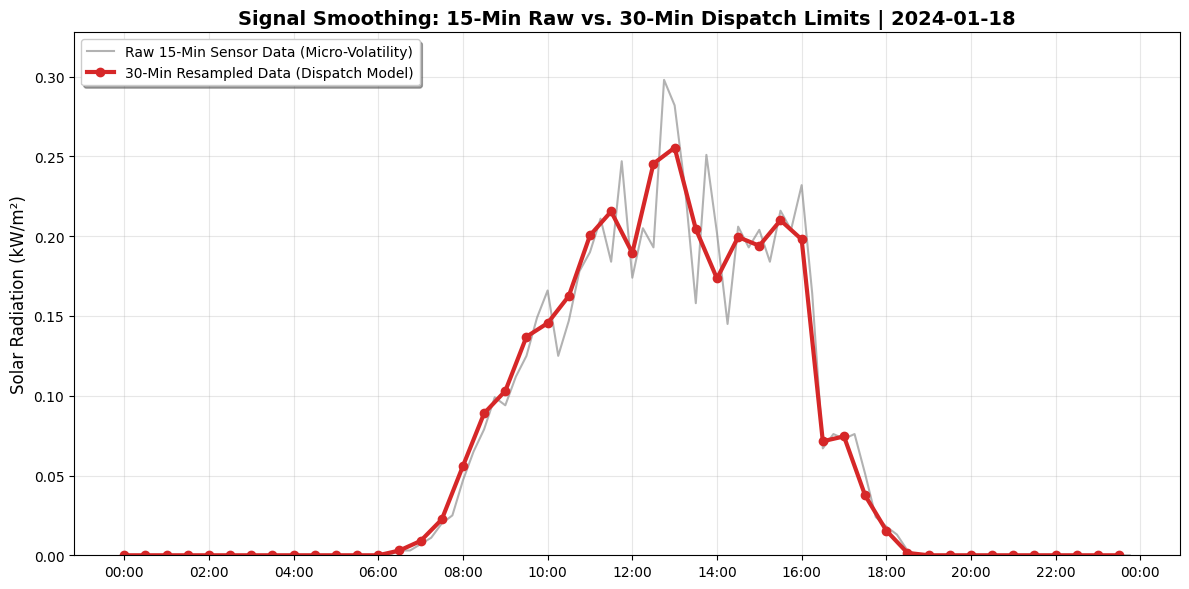

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_resolution_comparison(target_date):
    # 1. Grab the raw 15-minute data for the specific day
    # Assuming df_jun has a DatetimeIndex
    day_15m = df_jun.loc[target_date]
    
    # 2. Resample it to 30 minutes (taking the mean of every two 15-min blocks)
    day_30m = day_15m['solar_kw'].resample('30T').mean()

    # ==========================================
    # 🎨 THE COMPARISON PLOT
    # ==========================================
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot the RAW 15-minute data (Thinner, gray, showing all the noise)
    ax.plot(day_15m.index, day_15m['solar_kw'], 
            color='gray', linestyle='-', linewidth=1.5, alpha=0.6, 
            label='Raw 15-Min Sensor Data (Micro-Volatility)')
    
    # Plot the SMOOTHED 30-minute data (Thick, red, with markers for dispatch points)
    ax.plot(day_30m.index, day_30m, 
            color='#d62728', linestyle='-', linewidth=3, marker='o', markersize=6, 
            label='30-Min Resampled Data (Dispatch Model)')

    # Visual Polish
    plt.title(f"Signal Smoothing: 15-Min Raw vs. 30-Min Dispatch Limits | {target_date}", 
              fontsize=14, fontweight='bold')
    ax.set_ylabel("Solar Radiation (kW/m²)", fontsize=12)
    
    # Cap the Y-axis slightly above the highest peak of the day
    ax.set_ylim(0, day_15m['solar_kw'].max() * 1.1) 
    
    # Clean up the X-axis to show hours clearly
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    ax.legend(loc='upper left', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run it on your peak day (or a highly volatile cloudy day to really show the smoothing)
plot_resolution_comparison('2024-01-18')

# Training

In [10]:
print("🧠 Training 6 Specialized Models for the 3-Hour Shift...")
df_ml = df_30.copy()

# ==========================================
# 1. TARGET GENERATION (30m to 180m)
# ==========================================
# We predict the DELTA (Future - Current)
steps = list(range(1, 7))   
solar_targets = [f'target_solar_diff_{s*30}m' for s in steps]

for s in steps:
    df_ml[f'target_solar_diff_{s*30}m'] = df_ml['solar_kw'].shift(-s) - df_ml['solar_kw']

# Drop the last few rows where targets are NaN (due to shifting)
df_final = df_ml.dropna()

# --- DEFINE FEATURES ---
# Ensure NO future targets are included in the feature set!
features = [c for c in df_final.columns if 'target' not in c]
print(f"Total Features for Training: {len(features)}")

# ==========================================
# 2. CHRONOLOGICAL SPLIT (80% Train, 20% Test)
# ==========================================
split_idx = int(len(df_final) * 0.8)
train, test = df_final.iloc[:split_idx], df_final.iloc[split_idx:]

# ==========================================
# 3. HYPERPARAMETERS (Optimized for < 50W Error)
# ==========================================
# We use Pseudo-Huber Loss to be robust against sudden "cloud spikes" 
# that would otherwise distort a standard MSE model.
xgb_params = {
    'objective': 'reg:pseudohubererror',
    'n_estimators': 350,   # High capacity for 49 features
    'max_depth': 8,        # Deep enough to catch complex interactions (e.g., Wind X * Humidity)
    'learning_rate': 0.03, # Slow and steady to find the global minimum
    'subsample': 0.8,      # Prevents overfitting to specific "freak" days
    'colsample_bytree': 0.7,
    'random_state': 42,
    'n_jobs': -1           # Use all CPU cores
}

# ==========================================
# 4. THE TRAINING LOOP
# ==========================================
models_3h = {}

for i, t in enumerate(solar_targets):
    horizon_min = (i+1) * 30
    print(f"Training Model for T + {horizon_min}m...")
    
    m = xgb.XGBRegressor(**xgb_params)
    m.fit(train[features], train[t])
    
    models_3h[t] = m
    print(f"  ✅ Step {i+1} Ready.")

🧠 Training 6 Specialized Models for the 3-Hour Shift...
Total Features for Training: 49
Training Model for T + 30m...
  ✅ Step 1 Ready.
Training Model for T + 60m...
  ✅ Step 2 Ready.
Training Model for T + 90m...
  ✅ Step 3 Ready.
Training Model for T + 120m...
  ✅ Step 4 Ready.
Training Model for T + 150m...
  ✅ Step 5 Ready.
Training Model for T + 180m...
  ✅ Step 6 Ready.


In [ ]:
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# ==========================================
# 5. PERCENTAGE ERROR (wMAPE) vs. BASELINE
# ==========================================
print("\n--- 📊 FINAL EVALUATION vs. HISTORICAL BASELINE (Daytime Only) ---")

# Calculate the historical mean (climatology) using the training set
climatology = train.groupby([train.index.hour, train.index.minute])['solar_kw'].mean()

for t in solar_targets:
    step_num = int(t.split('_')[-1].replace('m','')) // 30
    
    # 1. Predict AI RAMP and get absolute value
    preds_ramp = models_3h[t].predict(test[features])
    preds_abs = np.clip(test['solar_kw'].values + preds_ramp, 0, None)
    
    # 2. Get ACTUAL future values and the actual future TIMESTAMPS
    actual_abs = test['solar_kw'].shift(-step_num).values
    future_times = test.index + pd.Timedelta(minutes=step_num*30)
    
    # 3. Mask for Daytime (> 0.01 kW)
    mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
    
    # 4. Calculate AI Error (wMAPE)
    error_abs_ai = np.abs(actual_abs[mask] - preds_abs[mask])
    wmape_ai = (error_abs_ai.sum() / actual_abs[mask].sum()) * 100 
    
    # 5. Calculate Baseline Error (wMAPE)
    # Map the future timestamps to their historical average for that time of day
    baseline_preds = future_times[mask].map(lambda x: climatology.get((x.hour, x.minute), 0)).values
    error_abs_base = np.abs(actual_abs[mask] - baseline_preds)
    wmape_base = (error_abs_base.sum() / actual_abs[mask].sum()) * 100
    
    # 6. Calculate Watts (MAE) just for completeness
    mae_watts_ai = mean_absolute_error(actual_abs[mask], preds_abs[mask]) * 1000
    
    # Print the direct comparison
    improvement = wmape_base - wmape_ai
    print(f"Horizon +{step_num*30:3}m | MAE: {mae_watts_ai:5.1f} W/m² | AI Error: {wmape_ai:4.1f}% | Baseline: {wmape_base:4.1f}% | AI Beat Baseline by: {improvement:4.1f}%")


--- 📊 FINAL EVALUATION vs. HISTORICAL BASELINE (Daytime Only) ---
Horizon + 30m | MAE:  31.5 W/m² | AI Error: 17.1% | Baseline: 40.2% | AI Beat Baseline by: 23.1%
Horizon + 60m | MAE:  40.1 W/m² | AI Error: 21.8% | Baseline: 40.2% | AI Beat Baseline by: 18.3%
Horizon + 90m | MAE:  45.9 W/m² | AI Error: 25.0% | Baseline: 40.2% | AI Beat Baseline by: 15.2%
Horizon +120m | MAE:  50.1 W/m² | AI Error: 27.2% | Baseline: 40.2% | AI Beat Baseline by: 12.9%
Horizon +150m | MAE:  54.0 W/m² | AI Error: 29.3% | Baseline: 40.1% | AI Beat Baseline by: 10.8%
Horizon +180m | MAE:  56.3 W/m² | AI Error: 30.6% | Baseline: 40.1% | AI Beat Baseline by:  9.5%


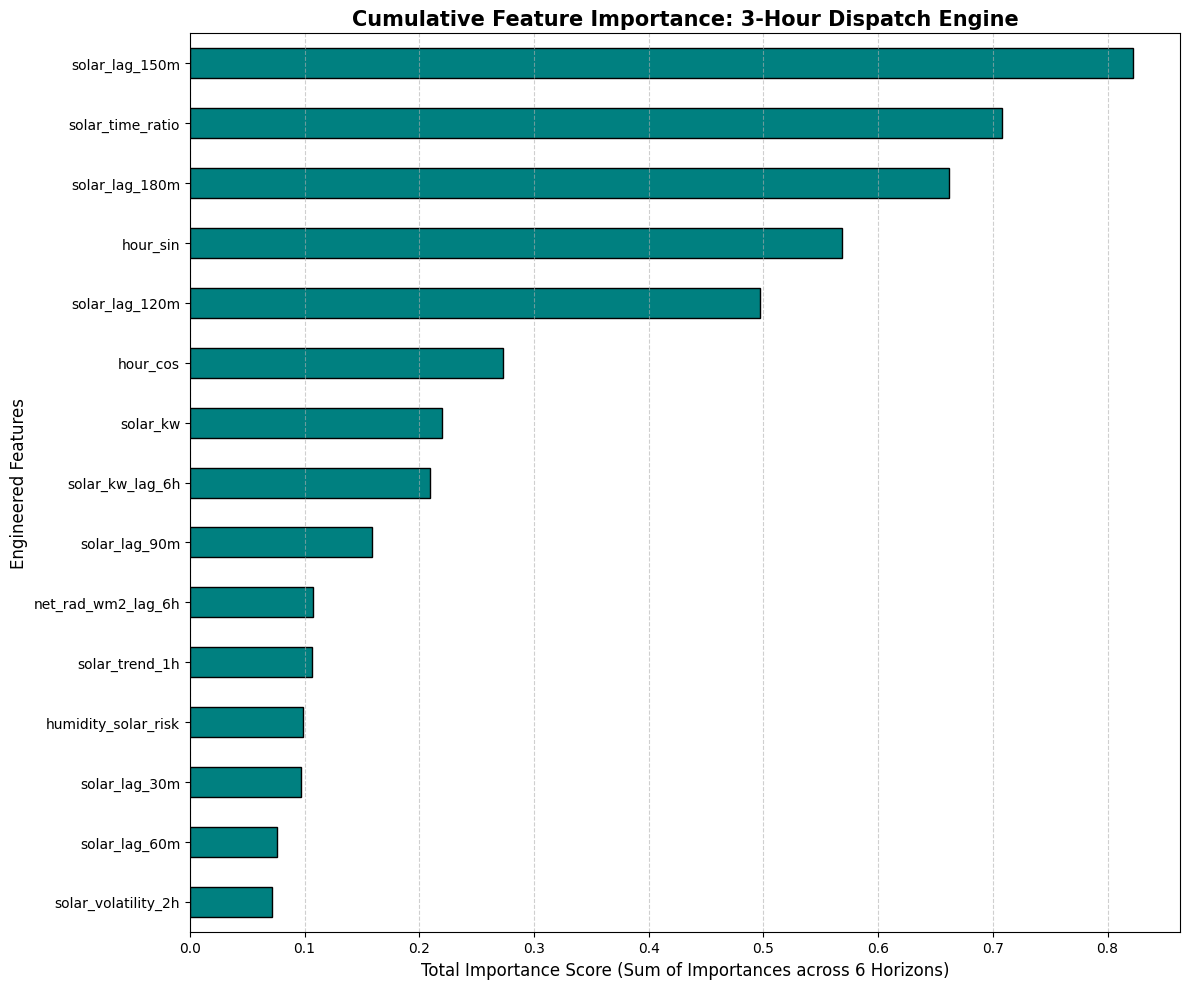

Top 10 Global Drivers for the 3-Hour Shift:
solar_lag_150m           0.822094
solar_time_ratio         0.708031
solar_lag_180m           0.661604
hour_sin                 0.568642
solar_lag_120m           0.497451
hour_cos                 0.272996
solar_kw                 0.219939
solar_kw_lag_6h          0.209108
solar_lag_90m            0.158669
net_rad_wm2_lag_6h       0.107523
solar_trend_1h           0.106335
humidity_solar_risk      0.098443
solar_lag_30m            0.097079
solar_lag_60m            0.075949
solar_volatility_2h      0.071659
net_rad_wm2              0.065976
v_solar                  0.060949
wind_x                   0.050831
soil_moisture_2          0.049994
soil_moisture_1          0.048910
wind_dir                 0.048225
wind_dir_lag_6h          0.047230
wind_y                   0.045443
rh_avg_lag_6h            0.045105
rh_avg_lag_24h           0.044108
wet_ground_lag_6h        0.043102
wind_speed_ms_lag_6h     0.042671
wind_speed_ms            0.041759
doy_

In [ ]:
# ==========================================
# 6. AGGREGATE FEATURE IMPORTANCE
# ==========================================
# Initialize a Series with zeros for all features
total_importance = pd.Series(0, index=features)

# Accumulate importance from each of the 6 models
for target in solar_targets:
    total_importance += models_3h[target].feature_importances_

# Sort the results to find the top drivers
total_importance = total_importance.sort_values(ascending=False)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 10))

# Plotting the top 15 features for the pitch
total_importance.head(15).plot(kind='barh', color='teal', edgecolor='black')

plt.title("Cumulative Feature Importance: 3-Hour Dispatch Engine", fontsize=15, fontweight='bold')
plt.xlabel("Total Importance Score (Sum of Importances across 6 Horizons)", fontsize=12)
plt.ylabel("Engineered Features", fontsize=12)
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Top 10 Global Drivers for the 3-Hour Shift:")
print(total_importance)

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# ==========================================
# 0. EXTRACT THE TOP 20 FEATURES
# ==========================================
# Assuming 'total_importance' is already in your memory from the previous run
top_20_features = total_importance.head(10).index.tolist()

print(f"🎯 Restricting model to Top 20 Features: {top_20_features}")

# ==========================================
# 1. DATA PREP & TARGET GENERATION
# ==========================================
print("\n🧠 Retraining 6 Specialized Models (Top 20 Features Only)...")
df_ml = df_30.copy()

# Predict the DELTA (Future - Current)
steps = list(range(1, 7)) 
solar_targets = [f'target_solar_diff_{s*30}m' for s in steps]

for s in steps:
    df_ml[f'target_solar_diff_{s*30}m'] = df_ml['solar_kw'].shift(-s) - df_ml['solar_kw']

# Drop rows with NaN targets
df_final = df_ml.dropna()

# 🌟 NEW: Restrict our features strictly to the Top 20 list
features = top_20_features

# ==========================================
# 2. CHRONOLOGICAL SPLIT (80% Train, 20% Test)
# ==========================================
split_idx = int(len(df_final) * 0.8)
train, test = df_final.iloc[:split_idx], df_final.iloc[split_idx:]

# ==========================================
# 3. HYPERPARAMETERS
# ==========================================
xgb_params = {
    'objective': 'reg:pseudohubererror',
    'n_estimators': 500,
    'max_depth': 10,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'random_state': 42,
    'n_jobs': -1
}

# ==========================================
# 4. THE TRAINING LOOP
# ==========================================
models_3h = {}

for i, t in enumerate(solar_targets):
    horizon_min = (i+1) * 30
    print(f"Training Model for T + {horizon_min}m...")
    
    m = xgb.XGBRegressor(**xgb_params)
    # 🌟 NEW: Model is only fed the 20 best features
    m.fit(train[features], train[t])
    
    models_3h[t] = m
    print(f"  ✅ Step {i+1} Ready.")

from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# ==========================================
# 5. PERCENTAGE ERROR (wMAPE) vs. BASELINE
# ==========================================
print("\n--- 📊 FINAL EVALUATION vs. HISTORICAL BASELINE (Daytime Only) ---")

climatology = train.groupby([train.index.hour, train.index.minute])['solar_kw'].mean()

for t in solar_targets:
    step_num = int(t.split('_')[-1].replace('m','')) // 30
    
    # 1. Predict AI RAMP and get absolute value
    preds_ramp = models_3h[t].predict(test[features])
    preds_abs = np.clip(test['solar_kw'].values + preds_ramp, 0, None)
    
    # 2. Get ACTUAL future values and timestamps
    actual_abs = test['solar_kw'].shift(-step_num).values
    future_times = test.index + pd.Timedelta(minutes=step_num*30)
    
    # 3. Mask for Daytime (> 0.01 kW)
    mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
    
    # 4. Calculate AI Error (wMAPE)
    error_abs_ai = np.abs(actual_abs[mask] - preds_abs[mask])
    wmape_ai = (error_abs_ai.sum() / actual_abs[mask].sum()) * 100 
    
    # 5. Calculate Baseline Error (wMAPE)
    baseline_preds = future_times[mask].map(lambda x: climatology.get((x.hour, x.minute), 0)).values
    error_abs_base = np.abs(actual_abs[mask] - baseline_preds)
    wmape_base = (error_abs_base.sum() / actual_abs[mask].sum()) * 100
    
    # 6. Calculate Watts (MAE)
    mae_watts_ai = mean_absolute_error(actual_abs[mask], preds_abs[mask]) * 1000
    
    # 7. Print the direct error comparison
    improvement = wmape_base - wmape_ai
    print(f"Horizon +{step_num*30:3}m | MAE: {mae_watts_ai:5.1f} W/m² | AI Error: {wmape_ai:4.1f}% | Baseline: {wmape_base:4.1f}% | AI Beat Baseline by: {improvement:4.1f}%")

🎯 Restricting model to Top 20 Features: ['solar_lag_150m', 'solar_time_ratio', 'solar_lag_180m', 'hour_sin', 'solar_lag_120m', 'hour_cos', 'solar_kw', 'solar_kw_lag_6h', 'solar_lag_90m', 'net_rad_wm2_lag_6h']

🧠 Retraining 6 Specialized Models (Top 20 Features Only)...
Training Model for T + 30m...
  ✅ Step 1 Ready.
Training Model for T + 60m...
  ✅ Step 2 Ready.
Training Model for T + 90m...
  ✅ Step 3 Ready.
Training Model for T + 120m...
  ✅ Step 4 Ready.
Training Model for T + 150m...
  ✅ Step 5 Ready.
Training Model for T + 180m...
  ✅ Step 6 Ready.

--- 📊 FINAL EVALUATION vs. HISTORICAL BASELINE (Daytime Only) ---
Horizon + 30m | MAE:  32.1 W/m² | AI Error: 17.5% | Baseline: 40.2% | AI Beat Baseline by: 22.7%
Horizon + 60m | MAE:  41.5 W/m² | AI Error: 22.6% | Baseline: 40.2% | AI Beat Baseline by: 17.6%
Horizon + 90m | MAE:  47.7 W/m² | AI Error: 25.9% | Baseline: 40.2% | AI Beat Baseline by: 14.2%
Horizon +120m | MAE:  52.1 W/m² | AI Error: 28.4% | Baseline: 40.2% | AI Beat Bas

In [ ]:
df_jun['solar_kw'].describe()

count    375325.000000
mean          0.099476
std           0.155232
min           0.000000
25%           0.000000
50%           0.002000
75%           0.161000
max           1.061000
Name: solar_kw, dtype: float64

C:\Users\Salvador\AppData\Local\Temp\ipykernel_19712\1659787111.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  target_time = pd.Timestamp(f"{target_date} {target_hour}:{target_minute}:00").floor('30T')


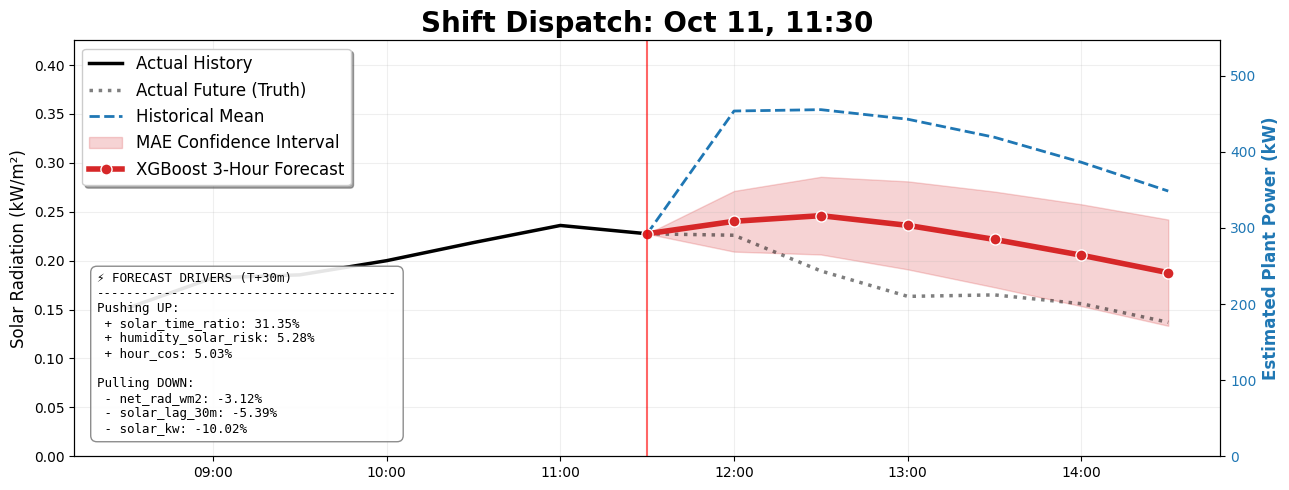

In [ ]:
def plot_operator_dashboard(target_date, target_hour, target_minute=0):
    # --- 1. SETUP & ALIGNMENT ---
    num_panels = 3024
    panel_area = 1.7
    total_area = num_panels * panel_area 
    efficiency_pr = 0.25 
    conv = total_area * efficiency_pr 
    
    mae_intervals = [0.03102, 0.03971, 0.04499, 0.04891, 0.05205, 0.05432]
    
    try:
        target_time = pd.Timestamp(f"{target_date} {target_hour}:{target_minute}:00").floor('30T')
    except Exception as e:
        print(f"Error: {e}"); return

    if target_time not in test.index:
        print(f"⚠️ Timestamp {target_time} not found in test set."); return

    current_features = test.loc[[target_time], features]
    current_val = test.loc[target_time, 'solar_kw']
    
    # --- 2. PREDICTIONS ---
    preds_abs = []
    for s in range(1, 7):
        t_key = f'target_solar_diff_{s*30}m'
        p_ramp = models_3h[t_key].predict(current_features)[0]
        preds_abs.append(np.clip(current_val + p_ramp, 0, None))
    
    lower_bounds = [current_val] + [max(0, p - m) for p, m in zip(preds_abs, mae_intervals)]
    upper_bounds = [current_val] + [p + m for p, m in zip(preds_abs, mae_intervals)]
    
    climatology = train.groupby([train.index.hour, train.index.minute])['solar_kw'].mean()
    future_times = [target_time + pd.Timedelta(minutes=s*30) for s in range(1, 7)]
    y_mean_baseline = [current_val] + [climatology.get((t.hour, t.minute), 0) for t in future_times]
    
    history = test.loc[target_time - pd.Timedelta(hours=3) : target_time]
    actual_future = [test.loc[t, 'solar_kw'] if t in test.index else np.nan for t in future_times]
    
    plot_times = [target_time] + future_times
    y_preds = [current_val] + preds_abs
    y_actuals = [current_val] + actual_future

    # --- 3. NATIVE SHAP CALCULATION ---
    dmatrix_x = xgb.DMatrix(current_features)
    booster = models_3h['target_solar_diff_30m'].get_booster()
    contribs = booster.predict(dmatrix_x, pred_contribs=True)[0]
    
    shap_vals = contribs[:-1]

    impacts = pd.Series(shap_vals, index=features).sort_values(ascending=False)
    push = impacts.head(3)
    push = push*100/impacts.abs().sum()  # Normalize to % of total impact
    pull = impacts.tail(3)
    pull = pull*100/impacts.abs().sum()  # Normalize to % of total impact

    # Calculate Spinning Reserve (Power scale)
    spin_reserve_kw = (current_val - lower_bounds[1]) * conv

    # ==========================================
    # 🎨 THE OPERATOR PLOT
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(13, 5))

    # Actuals & Baselines
    ax1.plot(history.index, history['solar_kw'], color='black', linewidth=2.5, label='Actual History')
    ax1.plot(plot_times, y_actuals, color='black', linestyle=':', linewidth=2.5, alpha=0.5, label='Actual Future (Truth)')
    ax1.plot(plot_times, y_mean_baseline, color='#1f77b4', linestyle='--', linewidth=2, label='Historical Mean')
    
    # Forecast & Confidence Fan
    ax1.fill_between(plot_times, lower_bounds, upper_bounds, color='#d62728', alpha=0.2, label='MAE Confidence Interval')
    ax1.plot(plot_times, y_preds, color='#d62728', linewidth=4, marker='o', markersize=8, label='XGBoost 3-Hour Forecast', markeredgecolor='white')
    
    # AXIS SCALING: Zooming in based on current data + baselines
    max_val_plotted = max(
        history['solar_kw'].max(), 
        max(upper_bounds), 
        max([v for v in y_actuals if not np.isnan(v)]),
        max(y_mean_baseline)  # 🌟 NEW: Prevents clipping the Historical Normal on cloudy days
    )
    
    # 20% headroom above the highest data point (Forecast, Truth, or Baseline)
    ax1.set_ylim(0, max_val_plotted * 1.2) 
    ax1.set_ylabel("Solar Radiation (kW/m²)", fontsize=12)
    ax1.grid(True, alpha=0.2)
    ax1.legend(loc='upper left', frameon=True, shadow=True, fontsize=12)

    # SECONDARY AXIS: Zoomed Power Map
    ax2 = ax1.twinx() 
    ax2.set_ylabel("Estimated Plant Power (kW)", color='#1f77b4', fontsize=12, fontweight='bold')
    ax2.set_ylim(0, (max_val_plotted * 1.2) * conv) 
    ax2.tick_params(axis='y', labelcolor='#1f77b4')

    # SHAP TEXT BOX (Forecast Drivers)
    shap_text = (
        f"⚡ FORECAST DRIVERS (T+30m)\n"
        f"----------------------------------------\n"
        f"Pushing UP:\n"
        f" + {push.index[0]}: {push.iloc[0]:.2f}%\n"
        f" + {push.index[1]}: {push.iloc[1]:.2f}%\n"
        f" + {push.index[2]}: {push.iloc[2]:.2f}%\n\n"
        f"Pulling DOWN:\n"
        f" - {pull.index[0]}: {pull.iloc[0]:.2f}%\n"
        f" - {pull.index[1]}: {pull.iloc[1]:.2f}%\n"
        f" - {pull.index[2]}: {pull.iloc[2]:.2f}%"
    )
    
    # Place text box in the lower left
    # (0.02, 0.05) provides a small margin from the axes
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
    ax1.text(0.02, 0.05, shap_text, transform=ax1.transAxes, fontsize=9,
             verticalalignment='bottom', horizontalalignment='left', 
             bbox=props, family='monospace')

    # Title with Actionable Metric
    plt.axvline(target_time, color='red', alpha=0.6)
    plt.title(f"Shift Dispatch: {target_time.strftime('%b %d, %H:%M')}", 
              fontsize=20, fontweight='bold')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    plt.tight_layout()
    plt.show()

# Run the Operator View
plot_operator_dashboard('2024-10-11', 11, 30)

In [14]:
test.columns

Index(['rain_mm', 'temp_c', 'rh_avg', 'rh_max', 'rh_min', 'solar_kw',
       'net_rad_wm2', 'wind_speed_ms', 'wind_dir', 'soil_moisture_1',
       'soil_moisture_2', 'soil_moisture_3', 'leaf_wetness',
       'leaf_wet_minutes', 'rain_mm_is_missing', 'hour_sin', 'hour_cos',
       'doy_sin', 'doy_cos', 'v_solar', 'a_solar', 'solar_volatility_2h',
       'v_humidity', 'humidity_solar_risk', 'solar_kw_lag_6h',
       'solar_kw_lag_24h', 'net_rad_wm2_lag_6h', 'net_rad_wm2_lag_24h',
       'temp_c_lag_6h', 'temp_c_lag_24h', 'rh_avg_lag_6h', 'rh_avg_lag_24h',
       'wind_speed_ms_lag_6h', 'wind_speed_ms_lag_24h', 'wind_dir_lag_6h',
       'wind_dir_lag_24h', 'rain_mm_lag_6h', 'rain_mm_lag_24h',
       'solar_lag_30m', 'solar_lag_60m', 'solar_lag_90m', 'solar_lag_120m',
       'solar_lag_150m', 'solar_lag_180m', 'solar_time_ratio', 'wind_x',
       'wind_y', 'wet_ground_lag_6h', 'solar_trend_1h',
       'target_solar_diff_30m', 'target_solar_diff_60m',
       'target_solar_diff_90m', 'target

In [15]:
import json
import numpy as np
import pandas as pd

def export_dashboard_json_dynamic(df, models_dict, filename="radiacion_solar.json"):
    print(f"⚙️ Formatting data for JSON export...")
    json_data = []
    
    # 1. IDENTIFY FEATURES
    # Exclude the target columns to get the exact feature list used for predictions
    feature_cols = [c for c in df.columns if 'target' not in c]
    
    # 2. PRE-CALCULATE ALL PREDICTIONS
    # We predict the 6 horizons for the entire dataframe at once for max speed
    preds_grid = {}
    for step_num in range(1, 7):
        horizon = f"{step_num*30}m"
        target_key = f'target_solar_diff_{horizon}'
        
        # Predict the ramp, add to current solar, clip at 0, and convert to Watts
        ramp = models_dict[target_key].predict(df[feature_cols])
        abs_watts = np.clip(df['solar_kw'].values + ramp, 0, None) * 1000
        preds_grid[step_num] = np.round(abs_watts, 2)
    
    # 3. BUILD THE JSON ROW BY ROW
    for idx in range(len(df)):
        row = df.iloc[idx]
        current_time = df.index[idx]
        
        # --- HISTÓRICO (Last 12 hours = 24 steps + current) ---
        start_idx = max(0, idx - 24)
        history_slice = df.iloc[start_idx : idx + 1]
        
        historico = []
        for t, val in history_slice['solar_kw'].items():
            historico.append({
                "timestamp": int(t.timestamp()),
                "radiacion": round(max(0, float(val) * 1000), 2)
            })
            
        # --- PREDICCIONES ---
        predicciones = {
            f"prediccion_{step}": float(preds_grid[step][idx]) 
            for step in range(1, 7)
        }
            
        # --- VARIABLES PREDICTORAS ---
        # Mapped perfectly to your actual DataFrame columns
        temp = row.get('temp_c', 0.0)
        humedad = row.get('rh_avg', 0.0)
        indice_claridad = row.get('solar_time_ratio', 0.0)
        
        variables = {
            "temperatura_actual": round(float(temp), 1),
            "humedad": round(float(humedad), 1),
            "nubosidad": 0.0,               # Safe Placeholder for UI
            "presion_atmosferica": 1012.5,  # Safe Placeholder for UI
            "indice_claridad": round(float(indice_claridad), 2)
        }
        
        # --- ASSEMBLE ---
        record = {
            "fecha": current_time.strftime('%Y-%m-%dT%H:%M:%SZ'),
            "historico": historico,
            "predicciones": predicciones,
            "variables_predictoras": variables
        }
        json_data.append(record)
        
    # 4. EXPORT TO FILE
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(json_data, f, indent=2, ensure_ascii=False)
        
    print(f"✅ Full JSON Feed exported to {filename} with {len(json_data)} records.")

# 🚀 Execute the export 
# (Make sure 'test' and 'models_3h' exist in your memory)
export_dashboard_json_dynamic(test, models_3h, "radiacion_solar.json")

⚙️ Formatting data for JSON export...
✅ Full JSON Feed exported to radiacion_solar.json with 37522 records.
